# 05 - Customer Segmentation (K-Means)
## Credit Risk Intelligence — Canadian Banking Project

## 1. Libraries & Setup

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load feature engineered dataset
df = pd.read_csv('../data/cs-training-features.csv')

## 2. Preparing Data for Clustering

In [4]:
# Select features most relevant for risk segmentation
features_for_clustering = [
    'RevolvingUtilizationOfUnsecuredLines',
    'total_late_payments',
    'DebtRatio',
    'MonthlyIncome',
    'age'
]

# Extract and scale features
X_cluster = df[features_for_clustering].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

## 3. Finding Optimal Number of Clusters

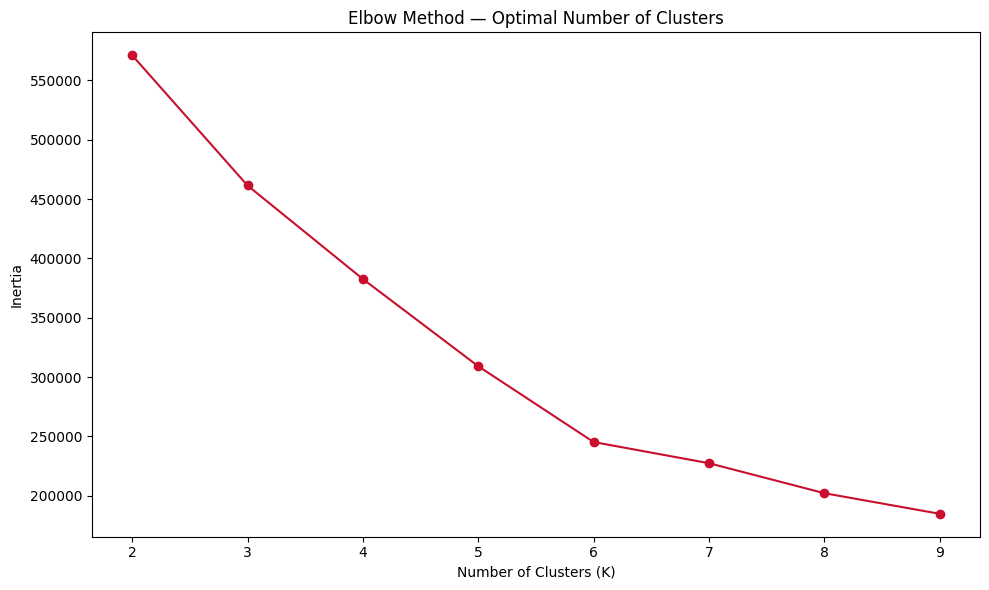

In [5]:
# Use elbow method to find optimal number of clusters
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', color='#C8102E')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [6]:
# Train K-Means with optimal K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze cluster profiles
cluster_profile = df.groupby('cluster')[features_for_clustering + ['SeriousDlqin2yrs']].mean().round(2)
print(cluster_profile)

         RevolvingUtilizationOfUnsecuredLines  total_late_payments  DebtRatio  \
cluster                                                                         
0                                        0.79                 1.05      56.48   
1                                        0.12                 0.13      49.93   
2                                        0.25                 0.26    2600.02   
3                                        0.16                 0.25       0.00   

         MonthlyIncome    age  SeriousDlqin2yrs  
cluster                                          
0              5776.60  44.55              0.17  
1              6854.15  55.11              0.02  
2              5068.58  54.07              0.04  
3           1858852.50  52.00              0.00  


In [7]:
# Remove extreme outliers before clustering
df_cluster = df[
    (df['MonthlyIncome'] < 50000) & 
    (df['DebtRatio'] < 10)
].copy()

print(f'Rows after filtering: {df_cluster.shape[0]}')

Rows after filtering: 118561


In [8]:
# Re-scale filtered data
X_cluster_clean = df_cluster[features_for_clustering].copy()
X_scaled_clean = scaler.fit_transform(X_cluster_clean)

# Re-train K-Means with clean data
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled_clean)

# Analyze new cluster profiles
cluster_profile = df_cluster.groupby('cluster')[features_for_clustering + ['SeriousDlqin2yrs']].mean().round(2)
print(cluster_profile)

         RevolvingUtilizationOfUnsecuredLines  total_late_payments  DebtRatio  \
cluster                                                                         
0                                        0.13                 0.14       0.30   
1                                        0.75                 3.64       0.42   
2                                        0.51                 0.21       0.41   
3                                        0.21                 0.25       5.35   

         MonthlyIncome    age  SeriousDlqin2yrs  
cluster                                          
0              7765.37  60.35              0.02  
1              5682.69  46.94              0.39  
2              5003.51  40.98              0.07  
3              3699.36  58.90              0.05  


In [9]:
# Map cluster numbers to business names
cluster_names = {
    0: 'Golden Seniors',
    1: 'Red Zone',
    2: 'Young & Stretched',
    3: 'Asset Rich Cash Poor'
}

df_cluster['cluster_name'] = df_cluster['cluster'].map(cluster_names)

# Save segmentation results for Power BI
df_cluster.to_csv('../data/customer_segments.csv', index=False)

print("Segmentation saved successfully!")
print(df_cluster['cluster_name'].value_counts())

Segmentation saved successfully!
cluster_name
Golden Seniors          61428
Young & Stretched       48111
Red Zone                 7772
Asset Rich Cash Poor     1250
Name: count, dtype: int64
